In [1]:
# imports
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mne
from sklearn.decomposition import PCA
from dataclasses import dataclass, field
from typing import Optional


# all the functions are in decoding_notebook_utils.py
from decoding_notebook_utils import run_decoding_for_quantity_and_epoch, load_epochs

In [2]:
# paths to the data and the output directory

# DERIVATIVES_DIR = Path("/where/you/downloaded/data")
# OUTPUT_DIR = Path("where/you/want/to/save/outputs")

# DERIVATIVES_DIR = Path("/home/sofia/Desktop/repositories/DatathonProject/derivatives")
DERIVATIVES_DIR = Path("/home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives")
OUTPUT_DIR = Path("/home/fmeyniel/projects/DatathonProject/decoding_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
def _mean_amplitude(data):
    return np.mean(np.abs(data), axis=0)

import numpy as np
from dataclasses import dataclass
from typing import Optional


@dataclass
class CPCAResult:
    """Results container for Circular PCA."""
    components: np.ndarray           # shape (n_components, n_features), complex
    scores: np.ndarray               # shape (n_samples, n_components), complex
    singular_values: np.ndarray      # shape (n_components,), real
    explained_variance: np.ndarray   # shape (n_components,), real
    explained_variance_ratio: np.ndarray  # shape (n_components,), real
    mean: np.ndarray                 # shape (n_features,), complex


class CircularPCA:
    """
    Circular (Proper) Complex PCA (CPCA).

    Operates on complex-valued data X ∈ C^{N×F} using the Hermitian
    covariance matrix C = (1/N) * X_c^H @ X_c, which guarantees real
    eigenvalues and orthonormal complex eigenvectors.

    The input is assumed to already be complex-valued (e.g. the analytic
    signal obtained via a prior Hilbert transform).

    Parameters
    ----------
    n_components : int or None
        Number of components to keep. If None, keeps all components.

    Raises
    ------
    ValueError
        If the input array is not complex-valued.
    """

    def __init__(self, n_components: Optional[int] = None):
        self.n_components = n_components
        self.result_: Optional[CPCAResult] = None

    def fit_transform(self, X: np.ndarray) -> CPCAResult:
        """
        Fit CPCA to X and return a CPCAResult.

        Parameters
        ----------
        X : complex array of shape (n_samples, n_features)
            Must be complex-valued. For neuroimaging, this is typically
            the analytic signal obtained via scipy.signal.hilbert applied
            along the time axis before calling this method.

        Returns
        -------
        CPCAResult
        """
        X = np.asarray(X)

        if not np.iscomplexobj(X):
            raise ValueError(
                "Input X must be complex-valued. If you have real-valued data "
                "(e.g. fMRI/EEG timeseries), apply scipy.signal.hilbert(X, axis=0) "
                "first to obtain the analytic signal."
            )

        # --- Center the data ---
        mean = X.mean(axis=0)
        X_c = X - mean

        n_samples, n_features = X_c.shape
        n_components = self.n_components or min(n_samples, n_features)

        # --- SVD on complex data ---
        # X_c = U @ diag(S) @ V^H  →  C = X_c^H @ X_c / N = V @ diag(S²/N) @ V^H
        U, S, Vh = np.linalg.svd(X_c, full_matrices=False)

        components = Vh[:n_components]                      # (k, n_features), complex
        scores = X_c @ Vh[:n_components].conj().T           # (n_samples, k), complex

        # --- Explained variance ---
        explained_variance = (S[:n_components] ** 2) / n_samples
        total_variance = (S ** 2).sum() / n_samples
        explained_variance_ratio = explained_variance / total_variance

        self.result_ = CPCAResult(
            components=components,
            scores=scores,
            singular_values=S[:n_components],
            explained_variance=explained_variance,
            explained_variance_ratio=explained_variance_ratio,
            mean=mean,
        )
        return self.result_

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Project new complex-valued data onto the fitted components.

        Parameters
        ----------
        X : complex array of shape (n_samples, n_features)

        Returns
        -------
        scores : complex array of shape (n_samples, n_components)
        """
        if self.result_ is None:
            raise RuntimeError("Call fit_transform before transform.")
        X = np.asarray(X)
        if not np.iscomplexobj(X):
            raise ValueError("Input X must be complex-valued.")
        X_c = X - self.result_.mean
        return X_c @ self.result_.components.conj().T


# Get average amplitude over trials in a frequency band

In [9]:
data = load_epochs('01','4', DERIVATIVES_DIR)
data.filter(l_freq=2, h_freq=4, picks='mag', verbose=False)
data.apply_hilbert(picks='mag', verbose=False)

Reading: /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif
Reading /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif ...


    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2629 matching events found
No baseline correction applied
0 projection items activated


Number of events,2629
Events,answers: 190cue: 749feedback: 749questions: 192response: 749
Time range,-1.000 – 0.990 s
Baseline,off


/tmp/ipykernel_2031041/2932981454.py:3: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  plt.plot(data.times, np.abs(data.get_data()[0, 0, :]), label='amplitude')
/tmp/ipykernel_2031041/2932981454.py:8: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  plt.plot(data.times, np.angle(data.get_data()[0, 0, :]), label='phase')


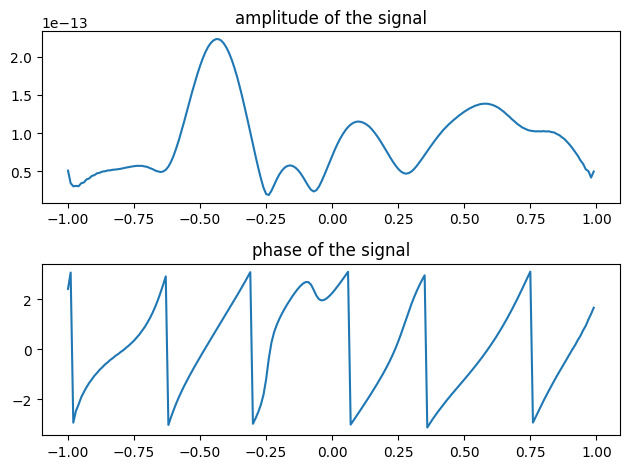

In [109]:
# plot the amplitude of the signal in the first trial, for the first channel
plt.subplot(2, 1, 1)
plt.plot(data.times, np.abs(data.get_data()[0, 0, :]), label='amplitude')
plt.title('amplitude of the signal')

# plot the phase of the signal in the first trial, for the first channel
plt.subplot(2, 1, 2)
plt.plot(data.times, np.angle(data.get_data()[0, 0, :]), label='phase')
plt.title('phase of the signal')
plt.tight_layout()

In [ ]:
out = data.average(picks='mag', method=_mean_amplitude, by_event_type=True)


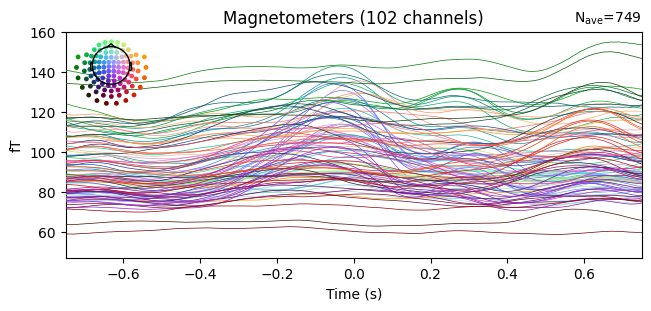

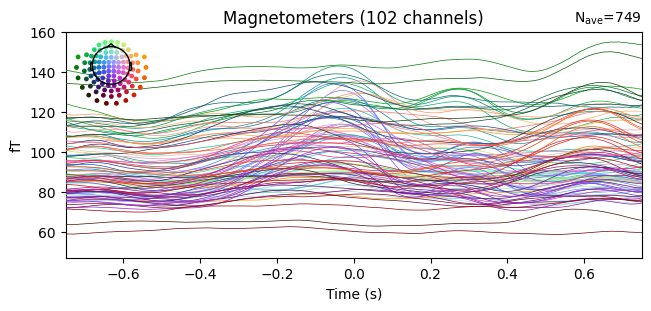

In [111]:
EVENT_TO_PLOT = 'response' # 'cue', 'response', 'feedback'
idx = np.where([_.comment==EVENT_TO_PLOT for _ in out])[0][0]

out[idx].plot(picks='mag', xlim=(-0.75, 0.75))

# Get average power (across trials and channels) per frequency band

In [10]:
FREQ_BANDS = [(0.5, 1), (1, 2), (2, 4), (4, 8), (8, 16), (0.5, 8)]
data = load_epochs('01','4', DERIVATIVES_DIR)
avg = {}
for l_freq, h_freq in FREQ_BANDS:
    data_band = data.copy().filter(l_freq=l_freq, h_freq=h_freq, picks='mag', verbose=False
                                   ).apply_hilbert(picks='mag', verbose=False)
    avg[(l_freq, h_freq)] = data_band.average(picks='mag', method=_mean_amplitude, by_event_type=True)


Reading: /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif
Reading /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif ...


    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2629 matching events found
No baseline correction applied
0 projection items activated


/tmp/ipykernel_2263389/2709314188.py:5: RuntimeWarning: filter_length (661) is longer than the signal (200), distortion is likely. Reduce filter length or filter a longer signal.
  data_band = data.copy().filter(l_freq=l_freq, h_freq=h_freq, picks='mag', verbose=False
/tmp/ipykernel_2263389/2709314188.py:5: RuntimeWarning: filter_length (331) is longer than the signal (200), distortion is likely. Reduce filter length or filter a longer signal.
  data_band = data.copy().filter(l_freq=l_freq, h_freq=h_freq, picks='mag', verbose=False
/tmp/ipykernel_2263389/2709314188.py:5: RuntimeWarning: filter_length (661) is longer than the signal (200), distortion is likely. Reduce filter length or filter a longer signal.
  data_band = data.copy().filter(l_freq=l_freq, h_freq=h_freq, picks='mag', verbose=False


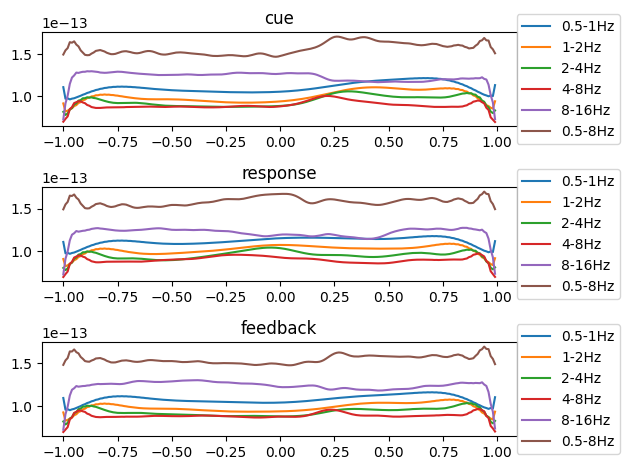

In [16]:
for n, event in enumerate(['cue', 'response', 'feedback']):
    idx = np.where([_.comment==event for _ in avg[FREQ_BANDS[0]]])[0][0]
    plt.subplot(3, 1, n+1)
    for l_freq, h_freq in FREQ_BANDS:
        plt.plot(avg[(l_freq, h_freq)][idx].times,
                np.mean(avg[(l_freq, h_freq)][idx].get_data(), axis=0), label=f'{l_freq}-{h_freq}Hz')
    plt.title(event)
    plt.legend(loc='center left',
               bbox_to_anchor=(1, 0.5),  # (x, y) in axes coordinates: just right of the axes
                borderaxespad=0.0)
plt.tight_layout()

# Make a time frequency map

In [ ]:
freq_bands = np.arange(1, 10, 1)
BAND_WIDTH = 1
epochs = load_epochs('01','4', DERIVATIVES_DIR)
amplitude_map = {}  # will store Evoked objects per band
for freq in freq_bands:
    ep = epochs.copy()
    ep.filter(freq - BAND_WIDTH/2, freq + BAND_WIDTH/2, picks='mag', verbose=False)
    ep.apply_hilbert(picks='mag', verbose=False)
    amplitude_map[freq] = ep                              # keep epochs for step 2

evoked_map = {}
for band_name, ep in amplitude_map.items():
    evoked_map[band_name] = ep.average(method=_mean_amplitude, by_event_type=True)


Reading: /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif
Reading /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2629 matching events found
No baseline correction applied
0 projection items activated
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Setting up band-pass filter from 0.5 - 1.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff freq

/tmp/ipykernel_2079222/1354775127.py:7: RuntimeWarning: filter_length (661) is longer than the signal (200), distortion is likely. Reduce filter length or filter a longer signal.
  ep.filter(freq - BAND_WIDTH/2, freq + BAND_WIDTH/2, picks='mag')
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.1s
[Parallel(n_jobs=

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Setting up band-pass filter from 1.5 - 2.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.50
- Lower transition bandwidth: 1.50 Hz (-6 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 2.50 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.50 Hz)
- Filter length: 221 samples (2.210 s)



/tmp/ipykernel_2079222/1354775127.py:7: RuntimeWarning: filter_length (221) is longer than the signal (200), distortion is likely. Reduce filter length or filter a longer signal.
  ep.filter(freq - BAND_WIDTH/2, freq + BAND_WIDTH/2, picks='mag')
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.1s
[Parallel(n_jobs=

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Setting up band-pass filter from 2.5 - 3.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.50
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.50 Hz)
- Upper passband edge: 3.50 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.50 Hz)
- Filter length: 165 samples (1.650 s)



...

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 4607 tasks      | elapsed:    0.3s
[Parallel(n_job

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Setting up band-pass filter from 7.5 - 8.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.50
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.50 Hz)
- Upper passband edge: 8.50 Hz
- Upper transition bandwidth: 2.12 Hz (-6 dB cutoff frequency: 9.56 Hz)
- Filter length: 165 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 4607 tasks      | elapsed:    0.3s
[Parallel(n_job

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Setting up band-pass filter from 8.5 - 9.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.50
- Lower transition bandwidth: 2.12 Hz (-6 dB cutoff frequency: 7.44 Hz)
- Upper passband edge: 9.50 Hz
- Upper transition bandwidth: 2.38 Hz (-6 dB cutoff frequency: 10.69 Hz)
- Filter length: 157 samples (1.570 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 4607 tasks      | elapsed:    0.3s
[Parallel(n_job

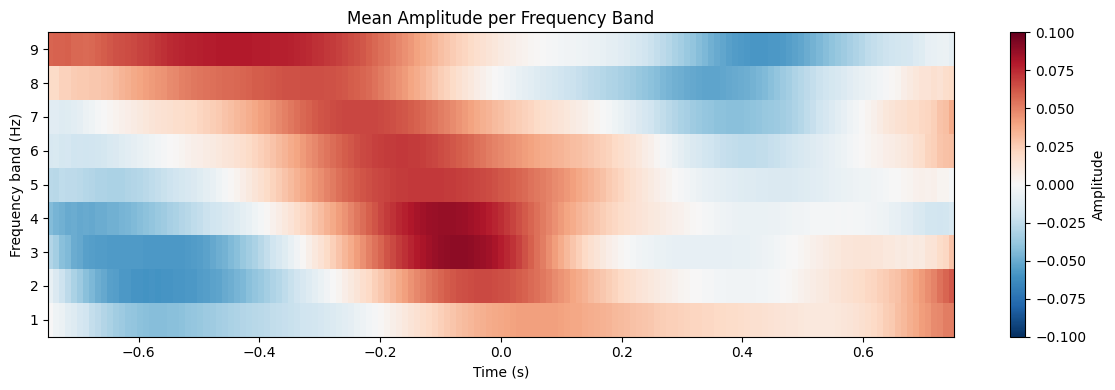

In [11]:
EVENT_TO_PLOT = 'response' # 'cue', 'response', 'feedback'
idx = np.where([_.comment==EVENT_TO_PLOT for _ in list(evoked_map.values())[0]])[0][0]

# pick one channel or average across all
ch_idx = 0  # or use np.mean over channels

times = epochs.times
band_names = list(evoked_map.keys())
tf_matrix = np.array([
    np.mean(evoked_map[b][idx].get_data(picks='mag'), axis=0)
    for b in band_names
])  # shape: (n_bands, n_times)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(
    np.log(tf_matrix) - np.log(np.mean(tf_matrix, axis=1, keepdims=True)),
    aspect="auto",
    origin="lower",
    extent=[times[0], times[-1], -0.5, len(band_names) - 0.5],
    cmap="RdBu_r",
    vmin=-0.1,
    vmax=0.1,
)
ax.set_yticks(range(len(band_names)))
ax.set_yticklabels(band_names)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency band (Hz)")
ax.set_xlim(-0.75, 0.75)
ax.set_title("Mean Amplitude per Frequency Band")
plt.colorbar(im, ax=ax, label="Amplitude")
plt.tight_layout()
plt.show()

to do:
- select the bands to look at
- do PCA to estimate the dimensionality of the data

# Extract signals from frequency bands of interest and check dimensionality

In [17]:
FREQ_BANDS = [(0.5, 2), (2, 4), (4, 8)]
data = load_epochs('01','4', DERIVATIVES_DIR)
data_band = {}
for l_freq, h_freq in FREQ_BANDS:
    data_band[(l_freq, h_freq)] = data.copy().filter(l_freq=l_freq, h_freq=h_freq, picks='mag', verbose=False
                                                     ).apply_hilbert(picks='mag', verbose=False)

Reading: /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif
Reading /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif ...


    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2629 matching events found
No baseline correction applied
0 projection items activated


/tmp/ipykernel_2263389/3332432939.py:5: RuntimeWarning: filter_length (661) is longer than the signal (200), distortion is likely. Reduce filter length or filter a longer signal.
  data_band[(l_freq, h_freq)] = data.copy().filter(l_freq=l_freq, h_freq=h_freq, picks='mag', verbose=False


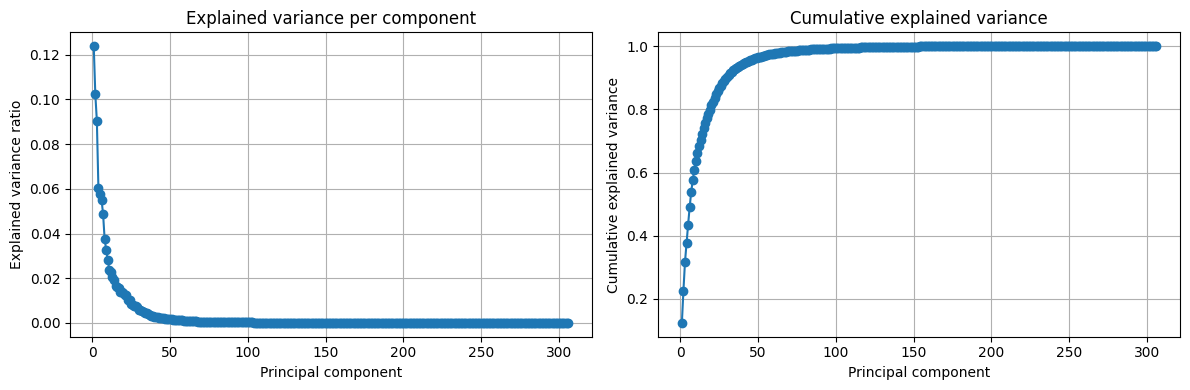

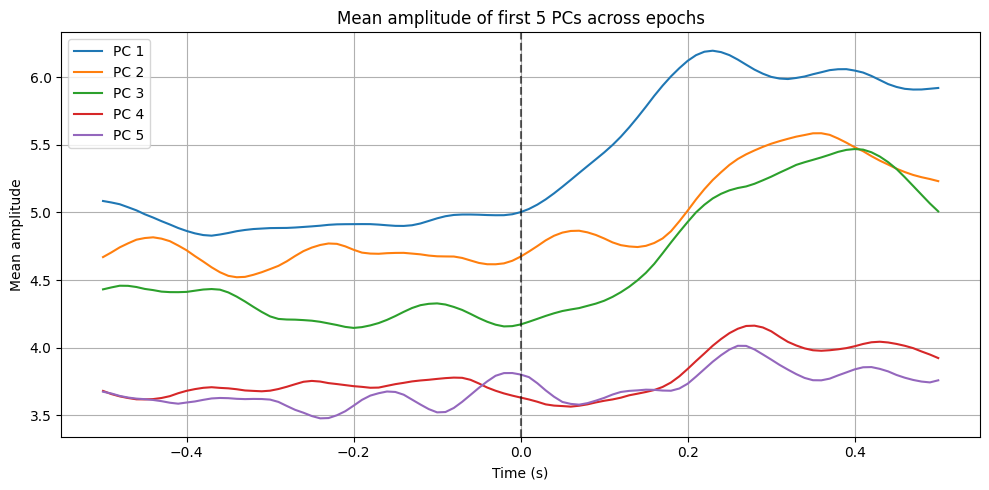

In [20]:
# Parameters for analysis
event_type = 'cue'  # 'cue', 'response', or 'feedback'
time_window = (-0.5, 0.5)  # (start, end) in seconds


# Build a feature matrix across frequency bands.
# Rows are features (band × channel) and columns are epoch × time samples.
band_features = []
for band in FREQ_BANDS:
    # Get the raw data and select by event type
    data_band_filtered = data_band[band][event_type].copy()
    data_band_array = data_band_filtered.get_data(picks='mag')
    
    # Extract time indices within the window
    times = data_band_filtered.times
    time_mask = (times >= time_window[0]) & (times <= time_window[1])
    data_band_array = data_band_array[:, :, time_mask]
    
    n_epochs, n_channels, n_times = data_band_array.shape
    band_features.append(data_band_array.reshape(n_epochs, n_channels, n_times).transpose(1, 0, 2).reshape(n_channels, n_epochs * n_times))

X = np.concatenate(band_features, axis=0)  # shape: (n_channels * n_bands, n_epochs * n_times)

# standardize features (because different bands have different power)
X = (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)

cpca = CircularPCA()
result = cpca.fit_transform(X.T) # PCA expects (n_samples, n_features)
explained_variance = result.explained_variance_ratio
cumulative_variance = np.cumsum(explained_variance)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual explained variance
axes[0].plot(np.arange(1, len(explained_variance) + 1), explained_variance, marker='o')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Explained variance per component')
axes[0].grid(True)

# Cumulative explained variance
axes[1].plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
axes[1].set_xlabel('Principal component')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative explained variance')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Compute amplitude for the first 5 PCs and average across epochs
n_pcs = min(5, result.scores.shape[1])
pc_scores = result.scores[:, :n_pcs]  # shape: (n_epochs * n_times, n_pcs)
pc_amplitude = np.abs(pc_scores)
pc_amplitude_epochs = pc_amplitude.reshape(n_epochs, n_times, n_pcs)
pc_amplitude_mean = np.mean(pc_amplitude_epochs, axis=0)  # shape: (n_times, n_pcs)

fig, ax = plt.subplots(figsize=(10, 5))
for pc_idx in range(n_pcs):
    ax.plot(times[time_mask], pc_amplitude_mean[:, pc_idx], label=f'PC {pc_idx + 1}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Mean amplitude')
ax.set_title('Mean amplitude of first 5 PCs across epochs')
ax.axvline(0, color='k', linestyle='--', alpha=0.6)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# decoding to-dos
- test decoding within each frequency band
- test with amplitude only, amplitude + phase, real + imaginary
- test with different number of components, especially if different frequency bands are combined

In [12]:
def _get_time_freq_features(data, time_freq_options):

    # filter per frequency band and apply Hilbert transform
    freq_bands = time_freq_options['FREQ_BANDS']
    data_band = []
    for l_freq, h_freq in freq_bands:
        # filter and apply Hilbert transform for this band
        _data_band = data.copy(
                ).filter(l_freq=l_freq, h_freq=h_freq, verbose=False
                ).apply_hilbert(verbose=False)
        data_band_array =_data_band.get_data()
        
        # Get data only from a specific time window
        if time_freq_options.get('time_window', None) is not None:
            times = _data_band.times
            time_mask = (times >= time_freq_options['time_window'][0]) & (times <= time_freq_options['time_window'][1])
            data_band_array = data_band_array[:, :, time_mask] # shape: (n_epochs, n_channels, n_times)
            
        data_band.append(data_band_array)
    
    # concatenate across bands
    data_band = np.concatenate(data_band, axis=1) # shape: (n_epochs, n_channels * n_bands, n_times)

    # do PCA if needed
    if time_freq_options.get('pca', False):
        n_epochs, n_channels_bands, n_times = data_band.shape
        # Reshape to (n_channels_bands, n_times * n_epochs)
        X = data_band.transpose(1, 2, 0).reshape(n_channels_bands, n_times * n_epochs)

        # standardize features (because different bands have different power)
        X = (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)

        # compute PCA
        cpca = CircularPCA(n_components=time_freq_options['pca'])
        result = cpca.fit_transform(X.T)  # X.T shape: (n_times * n_epochs, n_channels_bands)
        # result.scores shape: (n_times * n_epochs, n_pcs)
        # Reshape back to (n_epochs, n_pcs, n_times)
        data_band = result.scores.reshape(n_times, n_epochs, time_freq_options['pca']).transpose(1, 2, 0)

    # get requested features
    band_features = []
    for feature in time_freq_options['features']:
        if feature == 'amplitude':
            band_features.append(np.abs(data_band))
        elif feature == 'phase':
            band_features.append(np.angle(data_band))
        elif feature == 'real':
            band_features.append(np.real(data_band))
        elif feature == 'imag':
            band_features.append(np.imag(data_band))
        else:
            raise ValueError(f"Unknown feature: {feature}")

    # concatenate along channels axis
    # final shape: (n_epochs, n_features * n_bands, n_times)
    return np.concatenate(band_features, axis=1)



In [3]:
data = load_epochs('01','4', DERIVATIVES_DIR)
data = data['cue'].copy().pick_types(meg='mag')

time_freq_options = {
    'FREQ_BANDS': [(0.5, 2), (2, 4), (4, 8)],
    'feature_types': ['amplitude', 'phase'],
    'time_window': (-0.5, 0.5),
    'pca': 10
}

res = _get_time_freq_features(data, time_freq_options)


Reading: /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif
Reading /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2629 matching events found
No baseline correction applied
0 projection items activated
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


NameError: name '_get_time_freq_features' is not defined

In [4]:
data = load_epochs('01','4', DERIVATIVES_DIR)
data = data['cue'].copy().pick_types(meg='mag')

time_freq_options = {
    'FREQ_BANDS': [(0.5, 2), (2, 4), (4, 8)],
    'feature_types': ['amplitude', 'phase'],
    'time_window': (-0.5, 0.5),
    'pca': 10
}

# filter per frequency band and apply Hilbert transform
freq_bands = time_freq_options['FREQ_BANDS']
data_band = {}
for l_freq, h_freq in freq_bands:
    data_band[(l_freq, h_freq)] = data.copy(
            ).filter(l_freq=l_freq, h_freq=h_freq, verbose=False
            ).apply_hilbert(verbose=False)



Reading: /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif
Reading /home/fmeyniel/nasShare/projects/EXPLORE_PLUS/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif ...


    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2629 matching events found
No baseline correction applied
0 projection items activated
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/tmp/ipykernel_2297378/2878792879.py:16: RuntimeWarning: filter_length (661) is longer than the signal (200), distortion is likely. Reduce filter length or filter a longer signal.
  ).filter(l_freq=l_freq, h_freq=h_freq, verbose=False


In [9]:
# extract features per band
feature_type = 'amplitude'
band_features = []
for band in data_band.values():
    data_band_array = band.get_data()
    
    # Get data only from a specific time window
    if time_freq_options.get('time_window', None) is not None:
        times = band.times
        time_mask = (times >= time_freq_options['time_window'][0]) & (times <= time_freq_options['time_window'][1])
        data_band_array = data_band_array[:, :, time_mask] # shape: (n_epochs, n_channels, n_times)
        
    band_features.append(data_band_array)




/tmp/ipykernel_2297378/548508628.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data_band_array = band.get_data()
/tmp/ipykernel_2297378/548508628.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data_band_array = band.get_data()
/tmp/ipykernel_2297378/548508628.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data_band_array = band.get_data()


In [ ]:
# concatenate across bands
band_features = np.concatenate(band_features, axis=1) # shape: (n_epochs, n_channels * n_bands, n_times)

# do PCA if needed
if time_freq_options.get('pca', False):
    n_epochs, n_channels_bands, n_times = band_features.shape
    # Reshape to (n_channels_bands, n_times * n_epochs)
    X = band_features.transpose(1, 2, 0).reshape(n_channels_bands, n_times * n_epochs)

    # standardize features (because different bands have different power)
    X = (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)

    # compute PCA
    cpca = CircularPCA(n_components=time_freq_options['pca'])
    result = cpca.fit_transform(X.T)  # X.T shape: (n_times * n_epochs, n_channels_bands)
    # result.scores shape: (n_times * n_epochs, n_pcs)
    # Reshape back to (n_epochs, n_pcs, n_times)
    band_features = result.scores.reshape(n_times, n_epochs, time_freq_options['pca']).transpose(1, 2, 0)


In [11]:
band_features.shape

(749, 10, 101)